In [1]:
import os
from tqdm import tqdm
import random as rnd
import pandas as pd
import seaborn as sns
from services.PoseScoringService import PoseScoringService
from services.ProcessingPipelineService import ProcessingPipelineService

In [2]:
base_path = "./temp/dataset/handstand/"
video_paths = os.listdir(base_path)
pose_names = ["starting", "swing", "landing"]

In [ ]:
df = pd.DataFrame(columns=pose_names+["frame"])

pose_scoring_service = PoseScoringService()
for video_path in tqdm(video_paths[::16]):
    full_path = os.path.join(base_path, video_path)
    
    poses_scores, _ = pose_scoring_service.get_poses_from_video(full_path, "handstand")
    for frame_index, score in enumerate(poses_scores):
        new_row = []
        for pose_name in pose_names:
            new_row.append(score.get(pose_name, {"score": 0})["score"])
        
        new_row.append(frame_index)
        df.loc[len(df)] = new_row
    

  0%|          | 0/37 [00:00<?, ?it/s]

I0000 00:00:1767967228.320545   78698 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1767967228.346086   79095 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1767967228.615721   79063 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1767967229.658958   79064 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1767967229.714852   79068 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
  3%|▎         | 1/37 [00:06<03:41,  6.16s/it]I0000 00:00:1767967234.403607   78698 gl_context_egl.cc:

In [3]:
df.head()

,starting,swing,landing,frame
0,0.383346,0.102251,0.360817,0.0
1,0.375491,0.105093,0.358465,1.0
2,0.524334,0.054624,0.238515,2.0
3,0.513632,0.064455,0.256638,3.0
4,0.473253,0.085510,0.279531,4.0


<Axes: xlabel='frame'>

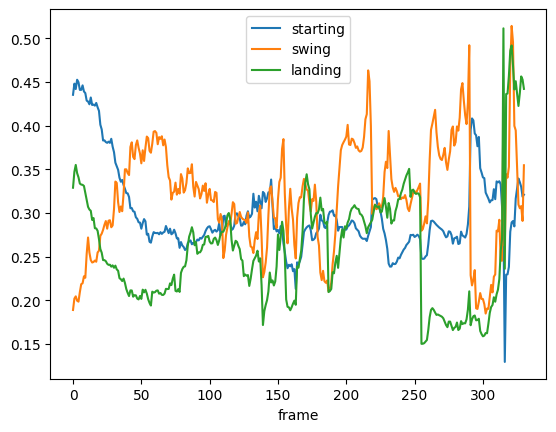

In [6]:
df_mean = df.groupby("frame")[["starting", "swing", "landing"]].mean()

df_mean.plot()

In [5]:
processing_pipeline_service = ProcessingPipelineService()
output_dir = "./temp/visualization_output"

random_video_name = rnd.choice(video_paths)
random_video_path = os.path.join(base_path, random_video_name)

output_video_path = os.path.join(output_dir, f"{random_video_name.split('.')[0]}_output.mp4")
output_json_path = os.path.join(output_dir, f"{random_video_name.split('.')[0]}_output.json")
output_pdf_path = os.path.join(output_dir, f"{random_video_name.split('.')[0]}_output.pdf")

try:
    processing_pipeline_service.analyze_video(
        str(random_video_path),
        str(output_video_path),
        str(output_pdf_path),
        str(output_json_path),
        "handstand",
    )
    print(f"Visualization complete for: {random_video_name}")
    print(f"Output files saved in: {output_dir}")
except Exception as e:
    print(f"An error occurred during visualization: {e}")

I0000 00:00:1767970633.035292   94986 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1767970633.044746   96421 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1767970618.844484   96411 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1767970619.860625   96412 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Visualization complete for: IMG_h37.MOV
Output files saved in: ./temp/visualization_output
